# **Read Me** (for Daniel and Edward)

This is the work we have done with David and Moses last semester. Feel free to continue down the same notebook or start from a new one in the same google drive folder. You will need the `star_cat_func.py` library for some of the functions to work. The notebooks is organized as follows:
1. Create a binary image for star extraction from the original All-Sky Imager image (only one frame per video is enough; the camera remains still throughout the video). This star extraction is done using the `load_data_image` function with input parameters `rotation` (the angle to rotate the image by to align it with true North up), `center` (the pixel location of the center to rotate the image around), and `threshold` (the pixel brightness threshold above which stars are detected, ranges from 0-255). Once the image is cleaned up, we create the `P` matrix containing the pixel coordinates of each star by finding the centroids of each star pixel cluster. This is done using the `get_star_centroids` function.
2. Create a simulated sky image using the observer's location and time of observation as inputs (based on the `star_catalog.csv`). We use the brightness parameter `Vmag_threshold` to filter out the stars that are too dim to be visible by the naked eye (and camera) from the catalog. Then we use the function `stars_to_polar_binary` with parameters `img_size` (pixel size of the simulated image, default=4000) and `point_size` (pixel size of each star, only relevant to visualize the image, default=1) to create the simulated image from the remaining stars.
3. Distort the simulated image to best match the original image. This is done using the `distort_image` function with parameters `t` (dilation from center, ranges 0-1) and `shifted_center` (where to shift the center so it is the same as the original image). The new image is created using the `redraw_with_user_xy` function, taking the matrix of distorted pixel coordinates `Q` of each star (output of `distort_image`) as input.
4. Calculate the distance matrix `D` to find the star pairs.
5. Future work (your contribution!): We have used multiple parameters to optimize our fitting so far, including `rotation`, `center`, `threshold` for processing of the original image, and `Vmag_threshold` and `t` for the creation of the distorted simulated image. In the example given in this notebook, the ground truth for `rotation` and `center` were used, and best guess estimates were used for `threshold`, `Vmag_threshold`, and `t`. The results are pretty good, but in a realistic scenario, we wouldn't know the truth values of `rotation` and `center`, and in order to make it fully automated, we would need the algorithm to make non-educated guesses for us. That's where ML comes in.

E.g.: The last part of the notebook presents a case where instead of choosing the truth value of `rotation` as our first guess, we iterate over possible `rotation` values from 0 to 90° and run the distance matching algorithm from there. You will notice that, although we would hope for `D` to be minimized at the truth value of `rotation=12.6°`, in reality `D` is minimized for wrong values of `rotation`. This shows that we cannot optimize over `rotation` alone but over all parameters at once so we can find a way to minimize `D` for the correct value of both `center` and `rotation`.

# **Library imports**

In [1]:
import cv2
import numpy as np
import star_cat_func as st
import matplotlib.pyplot as plt

# **1. Create a binary image for star extraction from a single frame of the original All-Sky Imager (ASI) footage**

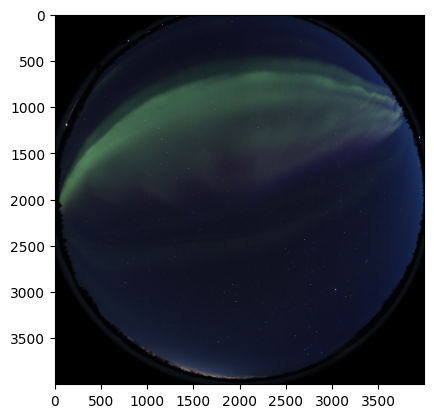

In [3]:
# Visualize the original image

ori_img_path = 'asi_frame.jpg'

ori_img = cv2.imread(ori_img_path, cv2.IMREAD_COLOR_RGB)

plt.imshow(ori_img)

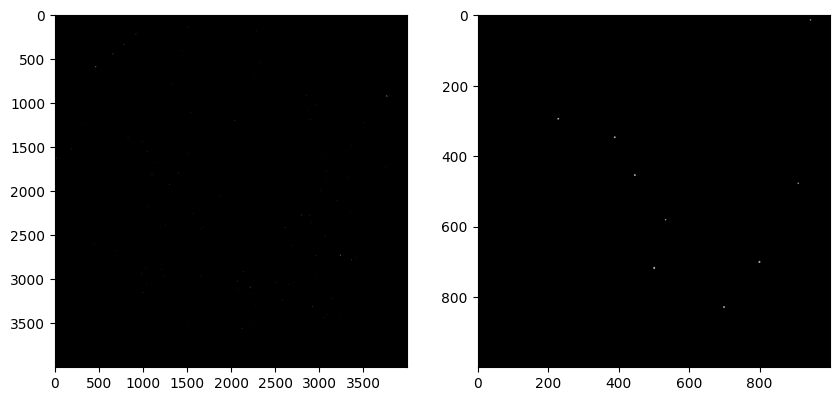

In [ ]:
# Create the binary image from known ground truth parameters

ori_brightness_threshold = 50  # estimated guess
ori_img_center = (2019, 1946)  # truth value
ori_rotation = 12.6            # truth value

ori_img_binary = st.load_data_image(ori_img_path, ori_rotation, ori_img_center, threshold=ori_brightness_threshold)

fig, ax = plt.subplots(1, 2, figsize=(10,10))
ax[0].imshow(ori_img_binary, cmap='gray')                       # the stars are very small so cannot be seen very well unless we zoom in
ax[1].imshow(ori_img_binary[1100:2100, 600:1600], cmap='gray')  # we zoom in on the Big Dipper

In [ ]:
# Extract the star location using centroid detection

P = st.get_star_centroids(ori_img_binary)

In [ ]:


print(P.shape) # number of stars, xy-coordinates

(89, 2)


# **Creating reference sky image in optimal conditions**

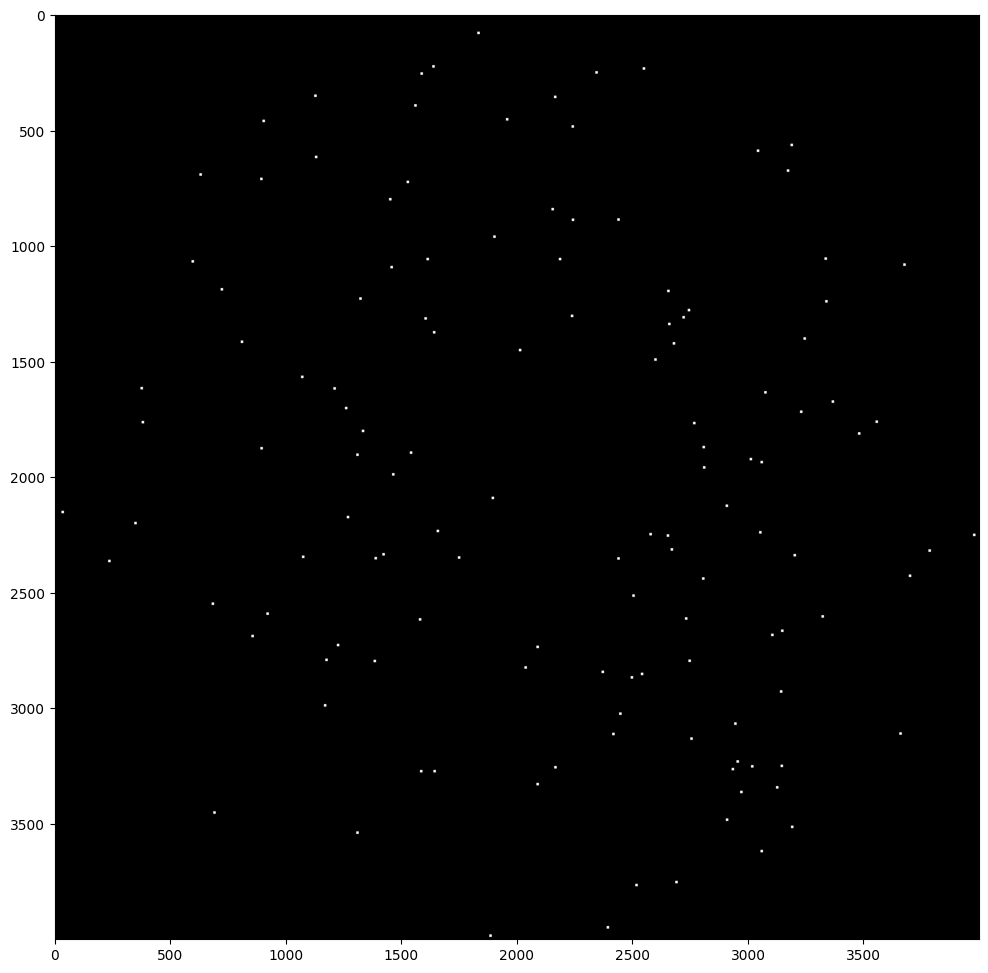

In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time
import pandas as pd

# Load the star catalog

Vmag_threshold = 3.5

stardf = pd.read_csv("/content/drive/MyDrive/epic_folder/star_catalog.csv", header=0)
bright_df = stardf[stardf["Vmag"] < Vmag_threshold].copy()

# Create Az and El arrays for 2025/03/17 06:04:46UT

time =  Time("2025-03-17 06:04:46", scale='utc')
user_loc = EarthLocation(lat=65.0782920060381 * u.deg,
                         lon=-147.74736306279442 * u.deg,
                         height=0 * u.m)

az, el = np.zeros((2, len(stardf['Name'])))

# Convert Ra/Dec to Az/El

coords = SkyCoord(ra=bright_df['Ra'].values * u.deg,
                  dec=bright_df['Dec'].values * u.deg,
                  frame='icrs')

altaz_frame = AltAz(obstime=time,
                    location=user_loc)

altaz = coords.transform_to(altaz_frame)

az = altaz.az.deg
el = altaz.alt.deg

# Create model image (without dilation)

img_model_linear, img_model_linear_xy_el_az = st.stars_to_polar_binary(el, az, rotation_deg=90, point_size=10)

plt.figure(figsize=(12, 12))
plt.imshow(img_model_linear, cmap='gray')

# **Dilate the model image produced by the star catalog to simulate an imperfect Allsky image**

(129, 2)


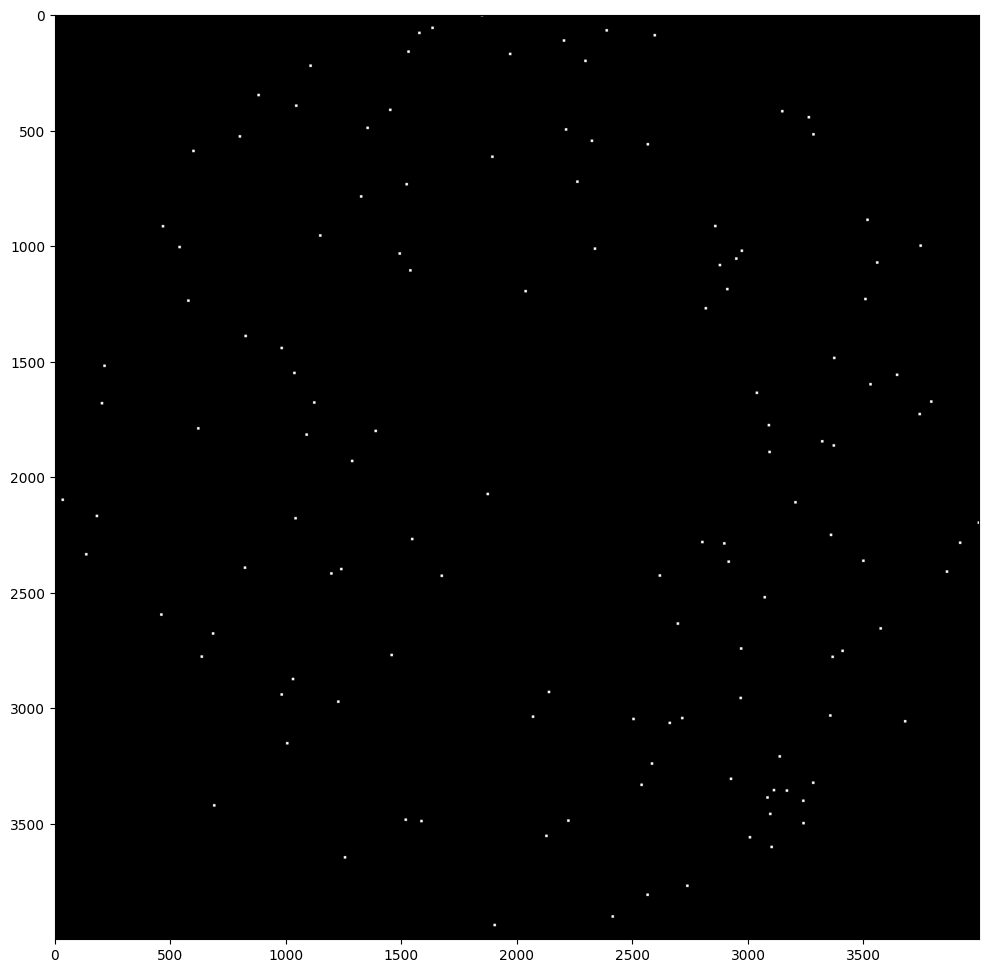

In [ ]:
# Compute dilation

def distort_image(img_model_linear, img_model_linear_xy_el_az, t, shifted_center=[0, 0]):

  center = img_model_linear.shape[0] // 2
  dist_lin = np.abs(np.sqrt((img_model_linear_xy_el_az[:, 0] - center)**2 + (img_model_linear_xy_el_az[:, 1] - center)**2))
  dist_cos = np.cos(np.deg2rad(img_model_linear_xy_el_az[:, 2])) * center

  dist_mix = dist_lin * t + dist_cos * (1 - t)

  new_x = shifted_center[0] - dist_mix * np.cos(np.deg2rad(90 - img_model_linear_xy_el_az[:, 3]))
  new_y = shifted_center[1] - dist_mix * np.sin(np.deg2rad(90 - img_model_linear_xy_el_az[:, 3]))

  new_xy = np.concatenate((new_x[:, None], new_y[:, None]), axis=1)
  print(new_xy.shape)

  return new_xy

# Create the dilated model

t = 0.3

new_xy = distort_image(img_model_linear, img_model_linear_xy_el_az, t, shifted_center=original_img_center)

img_model_dilated, img_model_dilated_xy_el_az = st.redraw_with_user_xy(img_model_linear_xy_el_az, new_xy, point_size=10)

Q = new_xy

plt.figure(figsize=(12, 12))
plt.imshow(img_model_dilated, cmap='gray')

# **Begin Euclidean Distance calculations $$ D = \sqrt(\mathbf{a}.\mathbf{1}_n^\top + \mathbf{1}_m.\mathbf{b}^\top - 2PQ^\top)$$**

In [ ]:
## Load our two images we want to compare

Q = get_star_centroids(img_model_dilated)
print(Q.shape)

## Prep all variables before we do any calculations

P_T = P.T
Q_T = Q.T
m = len(P)
print(P.shape)
n = len(Q)

onesM = np.ones(shape = (m, 1))
onesN = np.ones(shape = (n, 1))

a = np.dot(P, P.T)
b = np.dot(Q, Q.T)

a = np.diag(np.dot(P, P.T))
b = np.diag(np.dot(Q, Q.T))

a = a[:, None]
b = b[:, None]

## Distance computation

D = np.sqrt(np.matmul(a, onesN.T) + np.matmul(onesM, b.T) - 2 * np.matmul(P, Q.T))

print(D.shape)


(129, 2)
(89, 2)
(89, 129)


In [ ]:
matches = []
dist = 0
for i in range(D.shape[0]):
    j = np.argmin(D[i])
    dist_ij = D[i, j]
    matches.append((i, j, dist))
    dist += dist_ij
matches = np.array(matches)
## max_dist = 0  # adjust depending on scale
## filtered = matches[matches[:, 2] < max_dist]
filtered = matches

jStar = np.argmin(D, axis = 1)

# **Comparing the matched stars to check if mapping is correct**

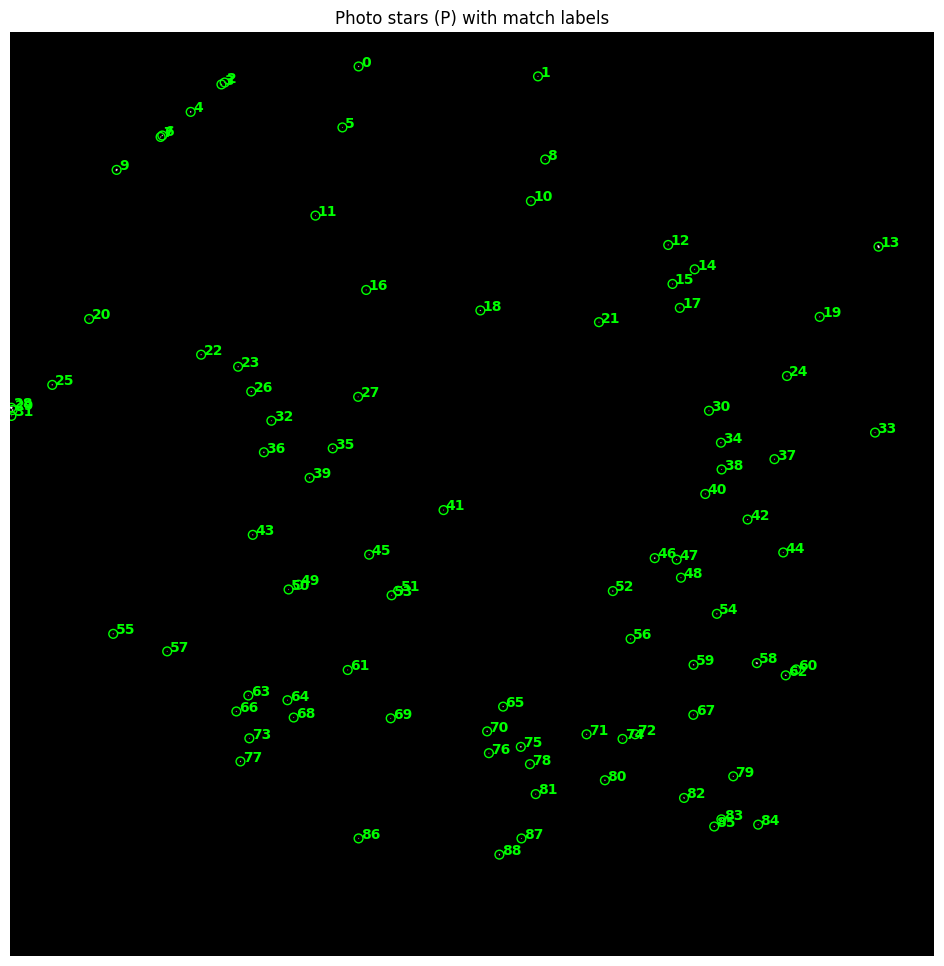

In [ ]:
plt.figure(figsize=(12, 12))
plt.imshow(img_data, cmap='gray')
plt.title("Photo stars (P) with match labels")
plt.axis('off')

# Plot and label only the matched subset
for idx, (i, j, dist) in enumerate(filtered):
    x, y = P[int(i)]
    plt.scatter(x, y, s=40, edgecolors='lime', facecolors='none')
    plt.text(x + 10, y, f"{idx}", color='lime', fontsize=10, fontweight='bold')


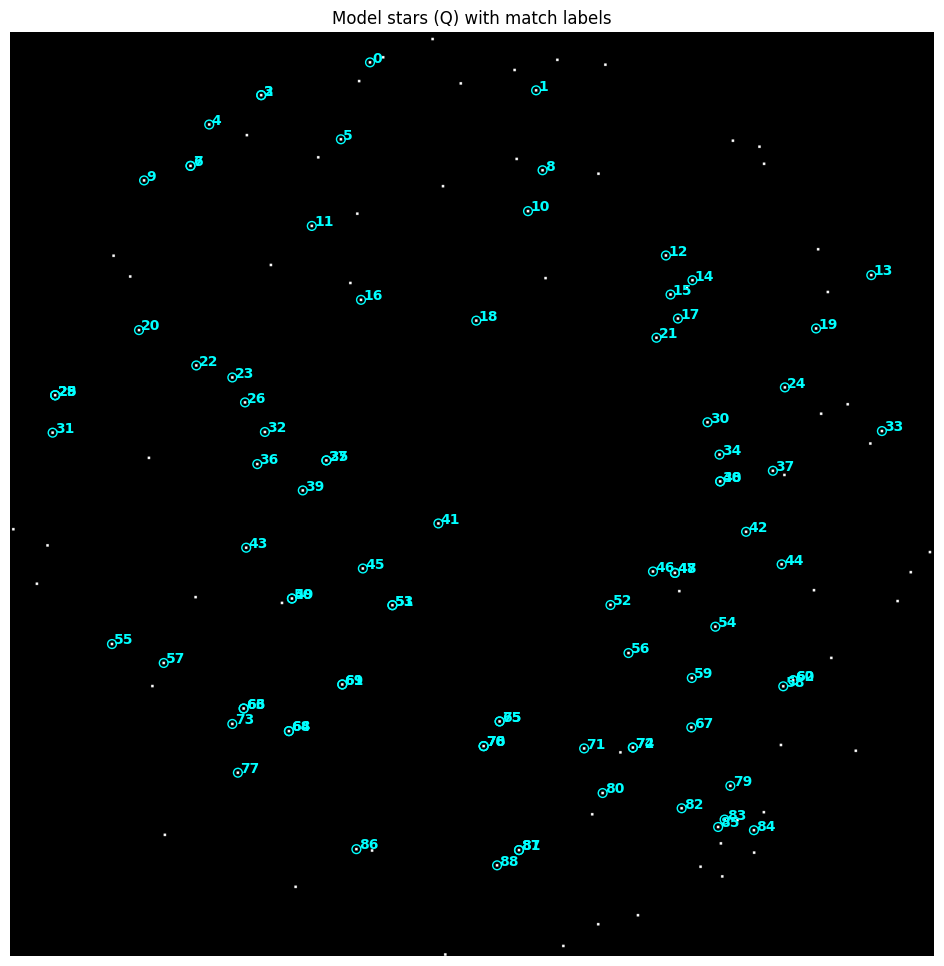

In [ ]:
plt.figure(figsize=(12, 12))
plt.imshow(img_model_dilated, cmap='gray')
plt.title("Model stars (Q) with match labels")
plt.axis('off')

for idx, (i, j, dist) in enumerate(filtered):
    x, y = Q[int(j)]
    plt.scatter(x, y, s=40, edgecolors='cyan', facecolors='none')
    plt.text(x + 10, y, f"{idx}", color='cyan', fontsize=10, fontweight='bold')


# **Side by side comparison**

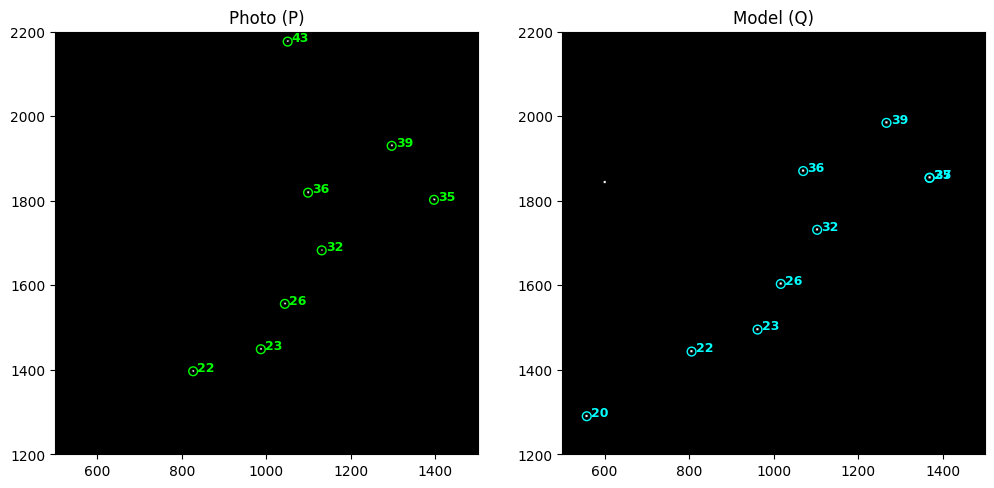

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Left: photo image
axes[0].imshow(img_data, cmap='gray')
axes[0].set_title("Photo (P)")
axes[0].set_xlim(500, 1500)
axes[0].set_ylim(1200, 2200)
for idx, (i, j, dist) in enumerate(filtered):
    x, y = P[int(i)]
    if (x >= 500) and (x <= 1500) and (y >= 1200) and (y <= 2200):
        axes[0].scatter(x, y, s=40, edgecolors='lime', facecolors='none')
        axes[0].text(x + 10, y, f"{idx}", color='lime', fontsize=9, fontweight='bold')

# Right: model image
axes[1].imshow(img_model_dilated, cmap='gray')
axes[1].set_title("Model (Q)")
axes[1].set_xlim(500, 1500)
axes[1].set_ylim(1200, 2200)
for idx, (i, j, dist) in enumerate(filtered):
    x, y = Q[int(j)]
    if (x >= 500) and (x <= 1500) and (y >= 1200) and (y <= 2200):
        axes[1].scatter(x, y, s=40, edgecolors='cyan', facecolors='none')
        axes[1].text(x + 10, y, f"{idx}", color='cyan', fontsize=9, fontweight='bold')

plt.show()


# **Make it a function**


In [ ]:
def match_stars(img_path, star_cat_path, time, loc, data_rotation, data_brightness_threshold, data_center, model_t_dilation, model_vmag_threshold, range_dist):

  # Load data image
  img_data = st.load_data_image(img_path, data_rotation, data_center, threshold=data_brightness_threshold)


  # Import star catalogue to create model image
  stardf = pd.read_csv(star_cat_path, header=0)
  bright_df = stardf[stardf["Vmag"] < model_vmag_threshold].copy()

  # Create Az and El arrays for model image
  time =  Time(time, scale='utc')
  user_loc = EarthLocation(lat=loc[0] * u.deg,
                          lon=loc[1] * u.deg,
                          height=0 * u.m)

  az, el = np.zeros((2, len(stardf['Name'])))

  # Convert Ra/Dec to Az/El for model image
  coords = SkyCoord(ra=bright_df['Ra'].values * u.deg,
                    dec=bright_df['Dec'].values * u.deg,
                    frame='icrs')

  altaz_frame = AltAz(obstime=time,
                      location=user_loc)

  altaz = coords.transform_to(altaz_frame)

  az = altaz.az.deg
  el = altaz.alt.deg

  # Create model image without dilation
  img_model_linear, img_model_linear_xy_el_az = st.stars_to_polar_binary(el, az, rotation_deg=90, point_size=5)

  # Create model image with dilation
  dist_lin = np.abs(np.sqrt((img_model_linear_xy_el_az[:, 0] - 2000)**2 + (img_model_linear_xy_el_az[:, 1] - 2000)**2))
  dist_cos = np.cos(np.deg2rad(img_model_linear_xy_el_az[:, 2])) * 2000

  dist_mix = dist_lin * t + dist_cos * (1 - model_t_dilation)

  new_x = 2000 - dist_mix * np.cos(np.deg2rad(90 - img_model_linear_xy_el_az[:, 3]))
  new_y = 2000 - dist_mix * np.sin(np.deg2rad(90 - img_model_linear_xy_el_az[:, 3]))

  new_xy = np.concatenate((new_x[:, None], new_y[:, None]), axis=1)

  img_model_dilated, img_model_dilated_xy_el_az = st.redraw_with_user_xy(img_model_linear_xy_el_az, new_xy, point_size=5)

  # Get centroids of data and model image stars
  P = get_star_centroids(img_data)
  Q = get_star_centroids(img_model_dilated)

  # Calculate distance to each star
  P_T = P.T
  Q_T = Q.T
  m = len(P)
  n = len(Q)

  onesM = np.ones(shape = (m, 1))
  onesN = np.ones(shape = (n, 1))

  a = np.dot(P, P.T)
  b = np.dot(Q, Q.T)

  a = np.diag(np.dot(P, P.T))
  b = np.diag(np.dot(Q, Q.T))

  a = a[:, None]
  b = b[:, None]

  D = np.sqrt(np.matmul(a, onesN.T) + np.matmul(onesM, b.T) - 2 * np.matmul(P, Q.T))

  # Find matches
  matches = np.zeros((D.shape[0], 3))
  for i in range(D.shape[0]):
      j = np.argmin(D[i])
      dist = D[i, j]
      matches[i, :] = [i, j, dist]
  if range_dist is not None:
    filtered = matches[(matches[:, 2] <= range_dist[1]) & (matches[:, 2] >= range_dist[0])] # contains star index in P (i) and Q (j) and dist to matched star for each match if dist < max_dist
  else:
    filtered = matches

  return img_data, img_model_linear, img_model_dilated, matches, filtered, D, P, Q

In [ ]:
img_path = '/content/drive/MyDrive/epic_folder/060446.jpg'
star_cat_path = '/content/drive/MyDrive/epic_folder/star_catalog.csv'
time = '2025-03-17 06:04:46'
loc = (65.0782920060381, -147.74736306279442)
data_rotation = 12.6
data_brightness_threshold = 50
data_center = (2019, 1946)
model_t_dilation = 0.3
model_vmag_threshold = 3.5
max_dist = 100

img_data, img_model_linear, img_model_dilated, matches, filtered, D, P, Q = match_stars(img_path, star_cat_path, time, loc, data_rotation, data_brightness_threshold, data_center, model_t_dilation, model_vmag_threshold, max_dist)


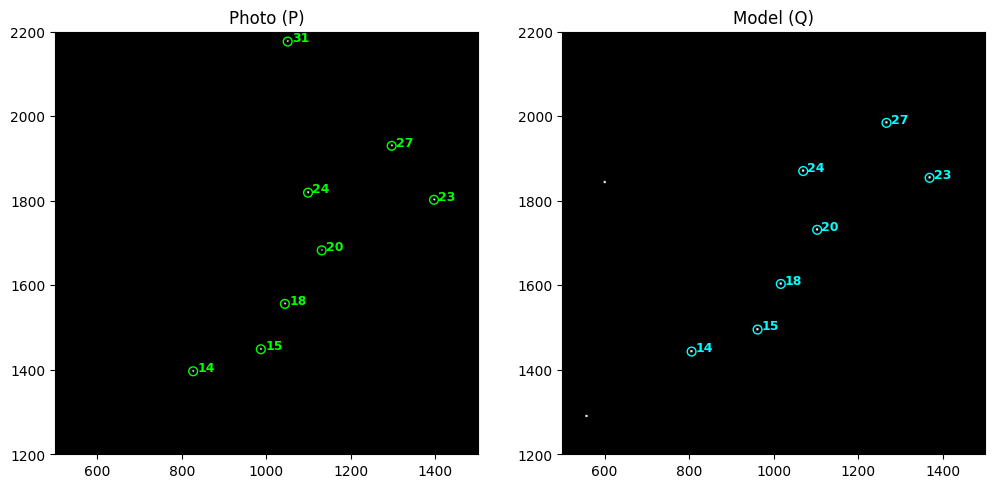

21559707.268431775


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Left: photo image
axes[0].imshow(img_data, cmap='gray')
axes[0].set_title("Photo (P)")
axes[0].set_xlim(500, 1500)
axes[0].set_ylim(1200, 2200)
for idx, (i, j, dist) in enumerate(filtered):
    x, y = P[int(i)]
    if (x >= 500) and (x <= 1500) and (y >= 1200) and (y <= 2200):
        axes[0].scatter(x, y, s=40, edgecolors='lime', facecolors='none')
        axes[0].text(x + 10, y, f"{idx}", color='lime', fontsize=9, fontweight='bold')

# Right: model image
axes[1].imshow(img_model_dilated, cmap='gray')
axes[1].set_title("Model (Q)")
axes[1].set_xlim(500, 1500)
axes[1].set_ylim(1200, 2200)
for idx, (i, j, dist) in enumerate(filtered):
    x, y = Q[int(j)]
    if (x >= 500) and (x <= 1500) and (y >= 1200) and (y <= 2200):
        axes[1].scatter(x, y, s=40, edgecolors='cyan', facecolors='none')
        axes[1].text(x + 10, y, f"{idx}", color='cyan', fontsize=9, fontweight='bold')

plt.show()

print(np.sum(D))

In [ ]:
# try for different img_data_rotation and model_t_dilation (and max_dist, data_brightness_threshold, model_Vmag_threshold)

In [ ]:
img_path = '/content/drive/MyDrive/epic_folder/060446.jpg'
star_cat_path = '/content/drive/MyDrive/epic_folder/star_catalog.csv'
time = '2025-03-17 06:04:46'
loc = (65.0782920060381, -147.74736306279442)
data_rotation = 12.6
data_brightness_threshold = 50
data_center = (2019, 1946)
model_t_dilation = 0.3
model_vmag_threshold = 3.5
max_dist = 100

img_data, img_model_linear, img_model_dilated, matches, filtered, D, P, Q = match_stars(img_path, star_cat_path, time, loc, data_rotation, data_brightness_threshold, data_center, model_t_dilation, model_vmag_threshold, max_dist)
np.sum(filtered[:, 2] / filtered.shape[0])


np.float64(52.96043526995477)

52.960435269954765


(array([ 2.,  2.,  4., 10., 25., 19.,  6.,  0.,  1.,  2.]),
 array([14.03566885, 22.34707189, 30.65847492, 38.96987796, 47.281281  ,
        55.59268403, 63.90408707, 72.21549011, 80.52689315, 88.83829618,
        97.14969922]),
 <BarContainer object of 10 artists>)

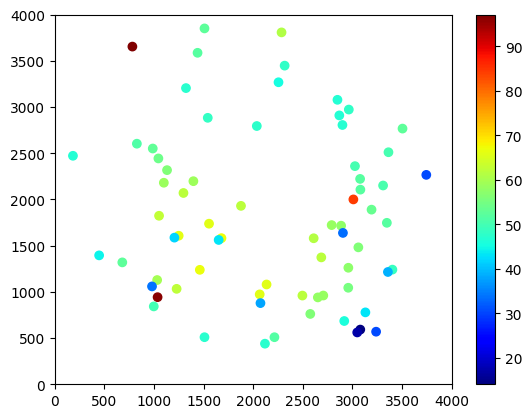

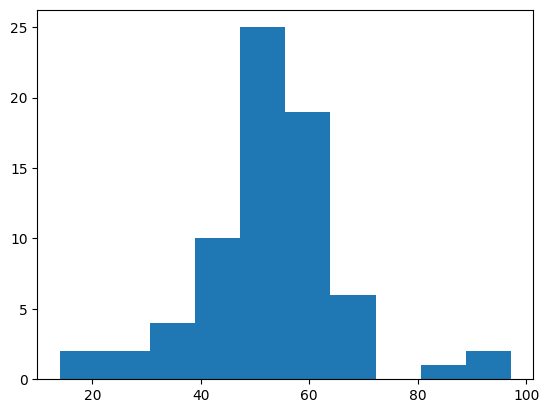

In [ ]:
plt.figure()
plt.scatter(P[np.astype(filtered[:,0], int), 0], 4000-P[np.astype(filtered[:,0], int), 1], c=filtered[:,2], cmap='jet')
plt.colorbar()
plt.xlim(0, 4000)
plt.ylim(0, 4000)
print(filtered[:,2].mean())

plt.figure()
plt.hist(filtered[:,2])

In [ ]:
# from tqdm import tqdm

# rotation_results = []
# degrees = np.arange(0, 90, 1)
# mean_dist = np.zeros(degrees.size)
# for i in tqdm(degrees):
#   img_data, img_model_linear, img_model_dilated, matches, filtered, D, P, Q = match_stars(img_path, star_cat_path, time, loc, i, data_brightness_threshold, data_center, model_t_dilation, model_vmag_threshold, max_dist)
#   rotation_results += [[np.mean(filtered[:, 2]), i, img_data, img_model_linear, matches, filtered]]

#   mean_dist[i] = np.mean(filtered[:, 2])


100%|██████████| 90/90 [01:04<00:00,  1.40it/s]


Text(0, 0.5, 'Mean distance (pixels)')

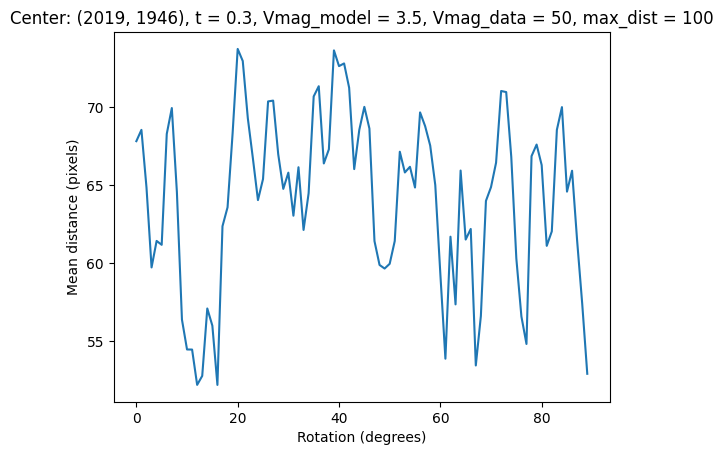

In [ ]:
plt.plot(degrees, mean_dist)
plt.title(f'Center: {data_center[0], data_center[1]}, t = {model_t_dilation}, Vmag_model = {model_vmag_threshold}, Vmag_data = {data_brightness_threshold}, max_dist = {max_dist}')
plt.xlabel('Rotation (degrees)')
plt.ylabel('Mean distance (pixels)')

In [ ]:
# degrees = np.arange(0, 90, 1)
# mean_dist_35_65 = np.zeros(degrees.size)
# for i in tqdm(degrees):
#   img_data, img_model_linear, img_model_dilated, matches, filtered, D, P, Q = match_stars(img_path, star_cat_path, time, loc, i, data_brightness_threshold, data_center, model_t_dilation, model_vmag_threshold, range_dist=(35, 65))

#   mean_dist_35_65[i] = np.mean(filtered[:, 2])

100%|██████████| 90/90 [01:03<00:00,  1.43it/s]


Text(0, 0.5, 'Mean distance (pixels)')

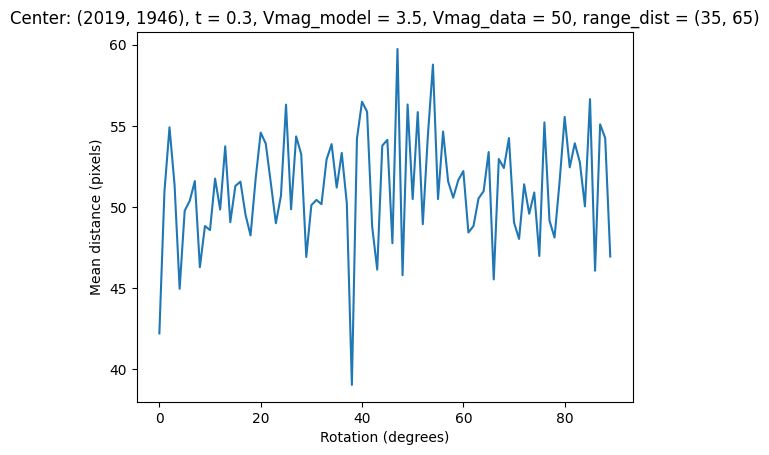

In [ ]:
plt.plot(degrees, mean_dist_35_65)
plt.title(f'Center: {data_center[0], data_center[1]}, t = {model_t_dilation}, Vmag_model = {model_vmag_threshold}, Vmag_data = {data_brightness_threshold}, range_dist = (35, 65)')
plt.xlabel('Rotation (degrees)')
plt.ylabel('Mean distance (pixels)')